In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "data/Electronic_sales_Sep2023-Sep2024.csv"

raw = pd.read_csv(DATA_PATH)
raw.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4

In [4]:
df = raw.rename(columns={
    "Customer ID": "customer_id",
    "Age": "age",
    "Gender": "gender",
    "Loyalty Member": "loyalty_member",
    "Product Type": "product_type",
    "SKU": "sku",
    "Rating": "rating",
    "Order Status": "order_status",
    "Payment Method": "payment_method",
    "Total Price": "total_price",
    "Unit Price": "unit_price",
    "Quantity": "quantity",
    "Purchase Date": "purchase_date",
    "Shipping Type": "shipping_type",
    "Add-ons Purchased": "addons_purchased",
    "Add-on Total": "addon_total",
})

df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'loyalty_member',
 'product_type',
 'sku',
 'rating',
 'order_status',
 'payment_method',
 'total_price',
 'unit_price',
 'quantity',
 'purchase_date',
 'shipping_type',
 'addons_purchased',
 'addon_total']

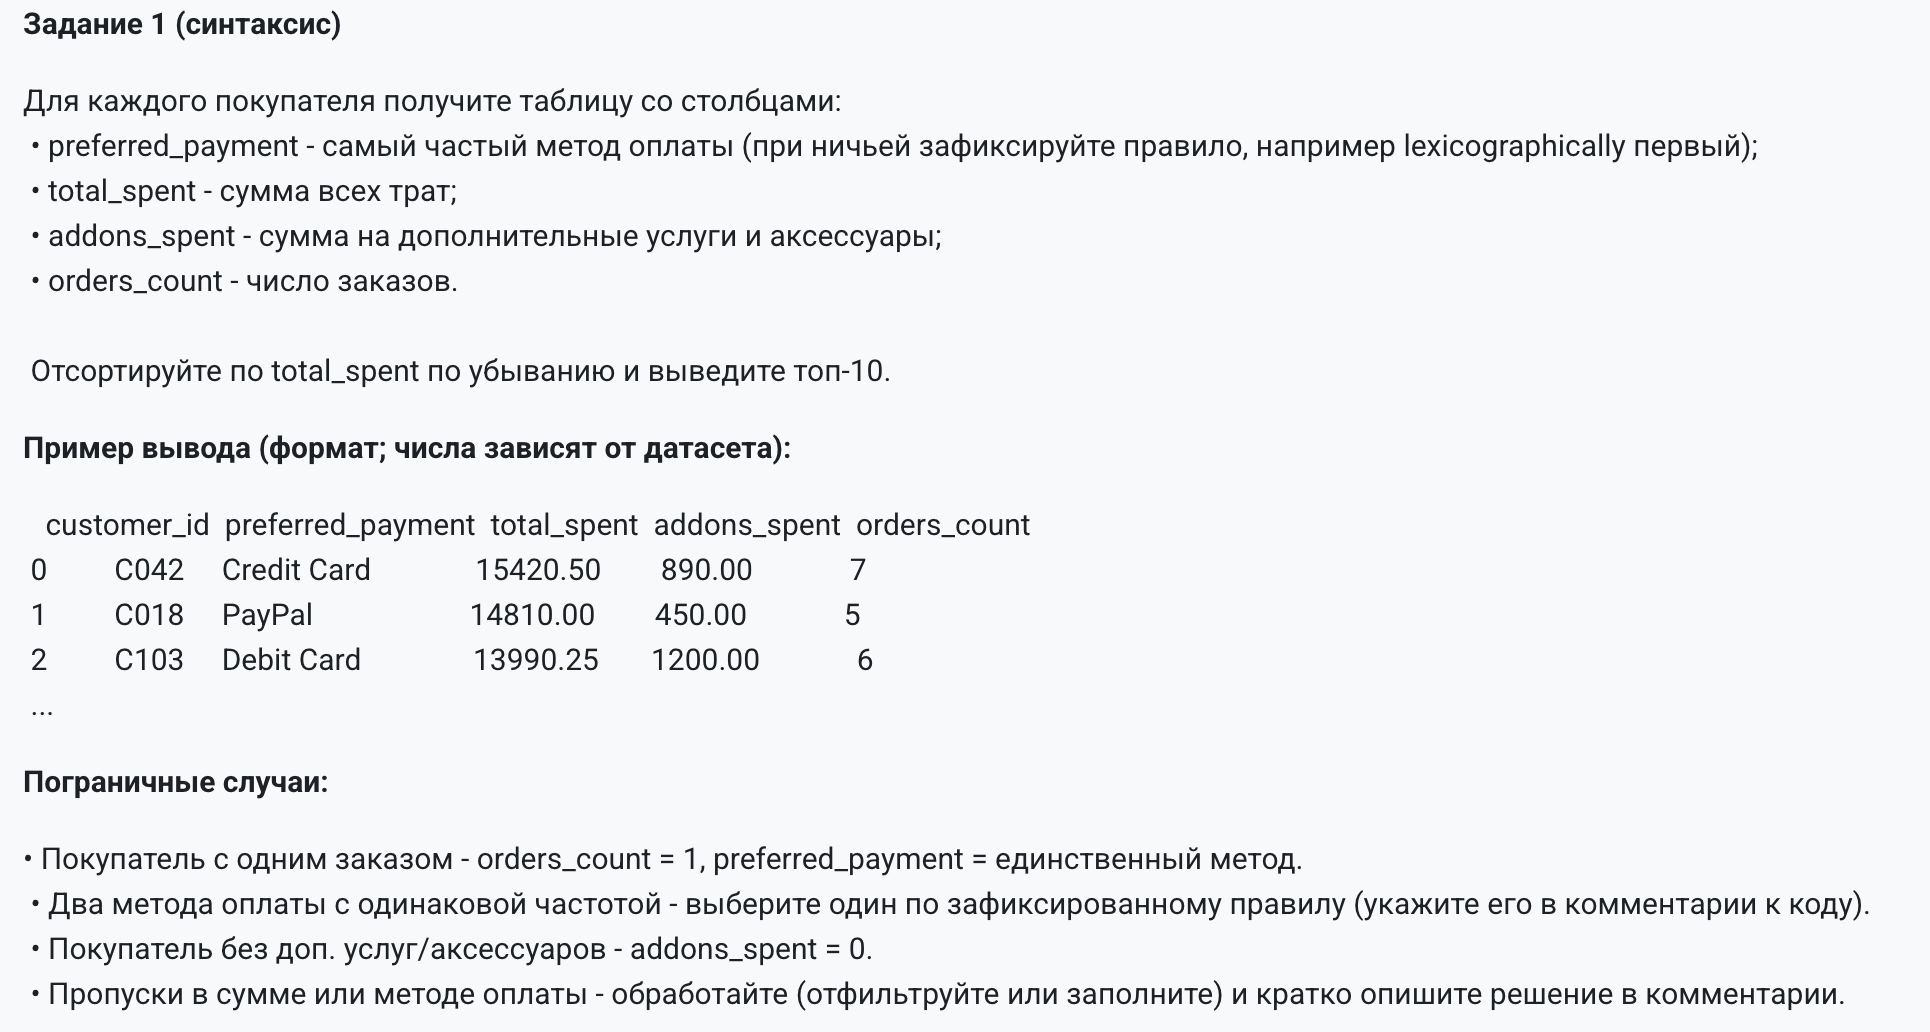

In [5]:
def preferred_payment(payments: pd.Series) -> str:
    counts = payments.value_counts()
    top_methods = counts[counts == counts.max()].index
    return sorted(top_methods)[0]


def customer_summary(df: pd.DataFrame) -> pd.DataFrame:
    clean_df = df.dropna(subset=["payment_method", "total_price"]).copy()
    clean_df["addon_total"] = clean_df["addon_total"].fillna(0)

    summary = (
        clean_df
        .groupby("customer_id")
        .agg(
            preferred_payment=("payment_method", preferred_payment),
            total_spent=("total_price", "sum"),
            addons_spent=("addon_total", "sum"),
            orders_count=("customer_id", "count"),
        )
        .reset_index()
    )
    return summary

In [6]:
summary = customer_summary(df)

top10 = summary.sort_values("total_spent", ascending=False).head(10).reset_index(drop=True)
top10

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
0,16357,Bank Transfer,34563.70,495.19,7
1,16863,PayPal,33035.92,486.17,5
2,13813,Credit Card,31830.16,268.64,5
3,11476,PayPal,31077.61,301.59,5
4,12276,Bank Transfer,30961.18,329.07,6
5,13635,Credit Card,30260.36,480.73,5
6,12749,Credit Card,29394.56,619.43,5
7,15399,PayPal,29084.88,305.39,3
8,12319,Bank Transfer,27352.32,226.38,3
9,19996,Bank Transfer,27296.78,432.12,6


In [7]:
single_order_customers = summary[summary["orders_count"] == 1]
single_order_customers.head()

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
2,1003,Cash,41.50,35.56,1
3,1004,Credit Card,83.00,65.78,1
6,1007,Credit Card,7120.71,55.48,1
7,1008,Cash,3379.32,65.85,1
8,1011,Credit Card,7911.90,70.17,1


In [8]:
no_addons_customers = summary[summary["addons_spent"] == 0]
no_addons_customers.head()

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
12,1016,Paypal,103.75,0.0,1
20,1027,Paypal,4747.14,0.0,1
21,1028,Debit Card,6758.64,0.0,1
28,1039,Credit Card,1729.21,0.0,1
31,1043,Debit Card,207.50,0.0,1


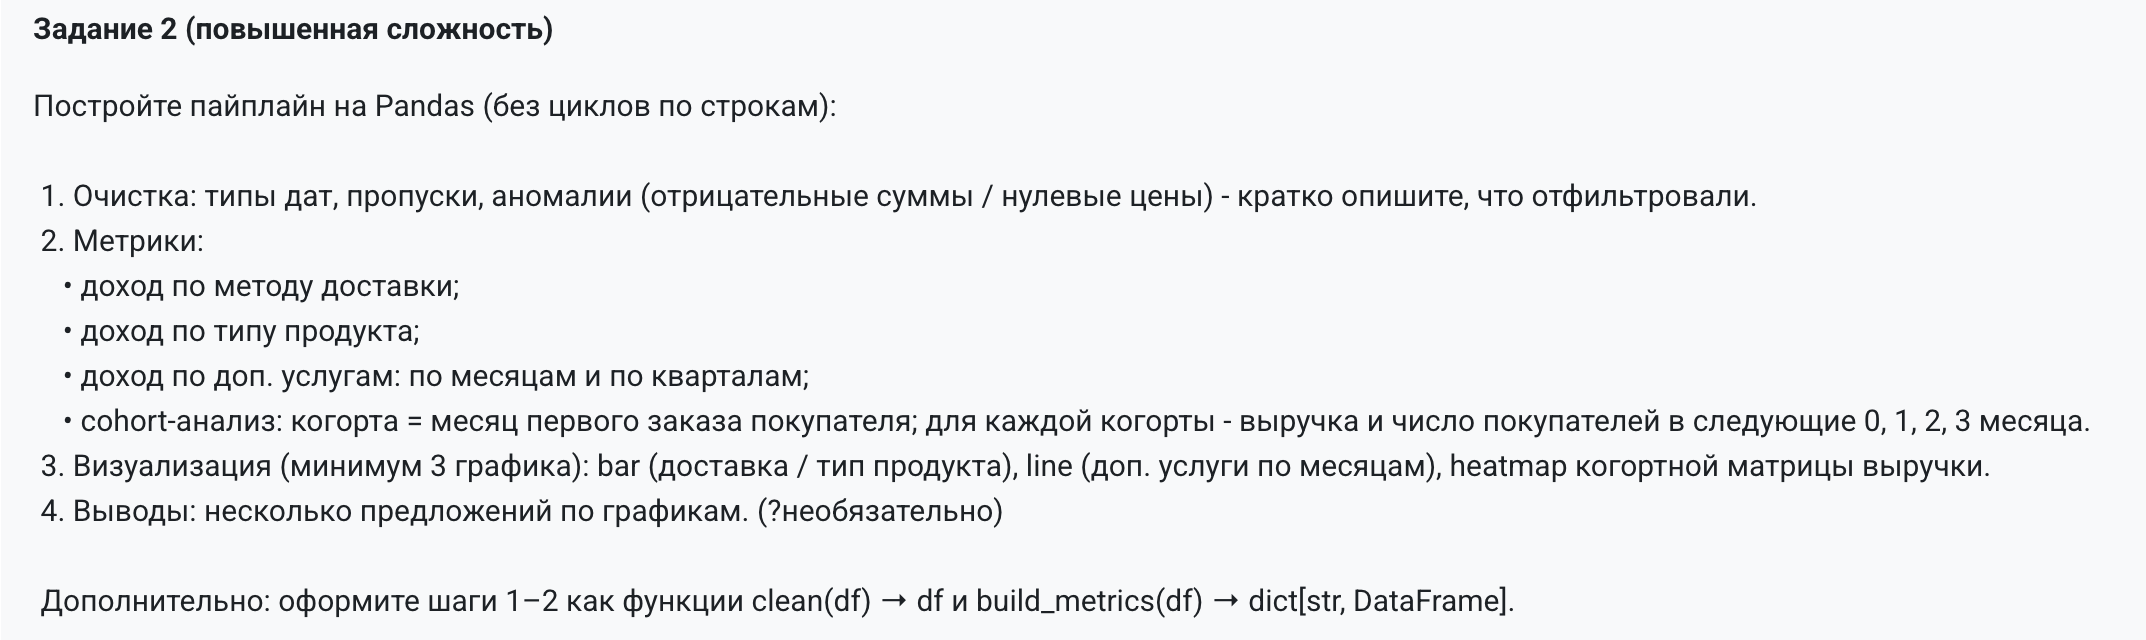

#### Очистка:
Что отфильтровали:
- `purchase_date` приводим к datetime
- строки, где дата не распозналась (`NaT`), убираем
- `total_price` приводим к числовому типу
- строки с пропущенной, нулевой или отрицательной ценой убираем — либо это аномалия, либо такие заказы не дают дохода в целом
- `addon_total` приводим к числовому типу и заполняем пропуски нулями (отсутствие допуслуг = 0)
- убираем отменённые заказы (`order_status == "Cancelled"`), тк отмененный заказ не должен попадать в доход.

In [9]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    clean_df = df.copy()

    clean_df["purchase_date"] = pd.to_datetime(clean_df["purchase_date"], errors="coerce")
    clean_df["total_price"] = pd.to_numeric(clean_df["total_price"], errors="coerce")
    clean_df["addon_total"] = pd.to_numeric(clean_df["addon_total"], errors="coerce").fillna(0)

    clean_df = clean_df.dropna(subset=["purchase_date", "total_price", "customer_id"])
    clean_df = clean_df[clean_df["total_price"] > 0]

    if "order_status" in clean_df.columns:
        clean_df = clean_df[clean_df["order_status"] != "Cancelled"]

    return clean_df.reset_index(drop=True)

In [10]:
df_clean = clean(df)

print(f"Строк до очистки: {len(df):,}")
print(f"Строк после очистки: {len(df_clean):,}")

Строк до очистки: 20,000
Строк после очистки: 13,432


In [13]:
def build_metrics(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    metrics: dict[str, pd.DataFrame] = {}

    if df.empty:
        metrics["revenue_by_shipping"] = pd.DataFrame(columns=["shipping_method", "revenue"])
        metrics["revenue_by_product_type"] = pd.DataFrame(columns=["product_type", "revenue"])
        metrics["addons_by_month"] = pd.DataFrame(columns=["month", "addons_revenue"])
        metrics["addons_by_quarter"] = pd.DataFrame(columns=["quarter", "addons_revenue"])
        metrics["cohort_revenue"] = pd.DataFrame()
        metrics["cohort_customers"] = pd.DataFrame()
        return metrics

    # доход по методу доставки
    metrics["revenue_by_shipping"] = (
        df
        .groupby("shipping_type")["total_price"]
        .sum()
        .reset_index()
        .rename(columns={"shipping_type": "shipping_method", "total_price": "revenue"})
        .sort_values("revenue", ascending=False)
        .reset_index(drop=True)
    )

    # доход по типу продукта
    metrics["revenue_by_product_type"] = (
        df
        .groupby("product_type")["total_price"]
        .sum()
        .reset_index()
        .rename(columns={"total_price": "revenue"})
        .sort_values("revenue", ascending=False)
        .reset_index(drop=True)
    )

    # доход по доп. услугам: по месяцам и по кварталам
    df_with_periods = df.assign(
        month=df["purchase_date"].dt.to_period("M").astype(str),
        quarter=df["purchase_date"].dt.to_period("Q").astype(str),
    )

    metrics["addons_by_month"] = (
        df_with_periods
        .groupby("month")["addon_total"]
        .sum()
        .reset_index()
        .rename(columns={"addon_total": "addons_revenue"})
        .sort_values("month")
        .reset_index(drop=True)
    )

    metrics["addons_by_quarter"] = (
        df_with_periods
        .groupby("quarter")["addon_total"]
        .sum()
        .reset_index()
        .rename(columns={"addon_total": "addons_revenue"})
        .sort_values("quarter")
        .reset_index(drop=True)
    )

    # когортный анализ
    order_month = df["purchase_date"].dt.to_period("M")
    first_purchase_month = df.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")

    cohort_df = df.assign(
        order_month=order_month,
        cohort_month=first_purchase_month,
    )
    cohort_df["cohort_index"] = (
        cohort_df["order_month"].astype(int) - cohort_df["cohort_month"].astype(int)
    )
    cohort_df = cohort_df[cohort_df["cohort_index"].between(0, 3)]

    metrics["cohort_revenue"] = (
        cohort_df
        .groupby(["cohort_month", "cohort_index"])["total_price"]
        .sum()
        .unstack("cohort_index")
    )

    metrics["cohort_customers"] = (
        cohort_df
        .groupby(["cohort_month", "cohort_index"])["customer_id"]
        .nunique()
        .unstack("cohort_index")
    )

    return metrics

In [14]:
metrics = build_metrics(df_clean)

metrics["revenue_by_shipping"]

,shipping_method,revenue
0,Standard,14387037.62
1,Expedited,8430385.58
2,Same Day,8292376.50
3,Overnight,5887722.52
4,Express,5632093.35


In [15]:
metrics["revenue_by_product_type"]

,product_type,revenue
0,Smartphone,14407835.84
1,Smartwatch,9398591.23
2,Laptop,8365905.25
3,Tablet,7722632.25
4,Headphones,2734651.00


In [16]:
metrics["addons_by_month"].head()

,month,addons_revenue
0,2023-09,5337.61
1,2023-10,26153.21
2,2023-11,24453.33
3,2023-12,22750.23
4,2024-01,93254.95


In [17]:
metrics["cohort_revenue"]

cohort_index,0,1,2,3
cohort_month,,,,
2023-09,283635.75,33456.62,26608.97,33037.33
2023-10,1521869.24,56062.66,104107.36,104115.98
2023-11,1307444.87,50714.25,118382.28,48411.54
2023-12,1122163.93,69367.01,50377.99,64964.23
2024-01,4212120.86,219854.68,355993.76,361010.49
2024-02,3479301.96,233334.29,253779.99,271156.10
2024-03,3424078.59,303436.44,244533.72,242932.43
2024-04,3115300.96,250017.51,265710.65,241513.21
2024-05,3066715.91,180702.17,238287.75,181550.20


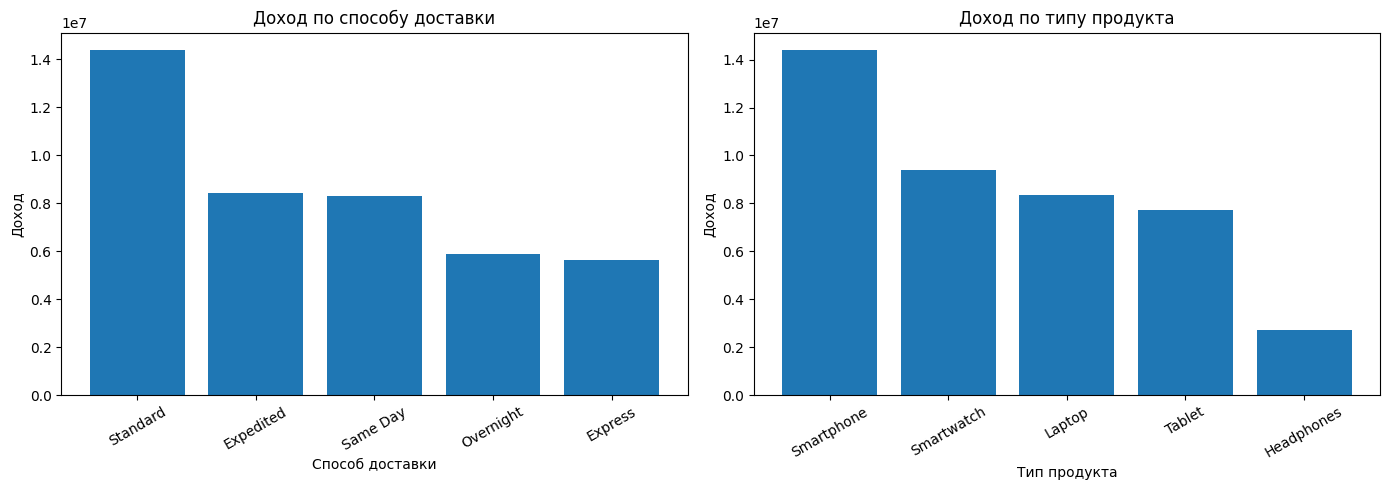

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    metrics["revenue_by_shipping"]["shipping_method"],
    metrics["revenue_by_shipping"]["revenue"],
)
axes[0].set_title("Доход по способу доставки")
axes[0].set_xlabel("Способ доставки")
axes[0].set_ylabel("Доход")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(
    metrics["revenue_by_product_type"]["product_type"],
    metrics["revenue_by_product_type"]["revenue"],
)
axes[1].set_title("Доход по типу продукта")
axes[1].set_xlabel("Тип продукта")
axes[1].set_ylabel("Доход")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

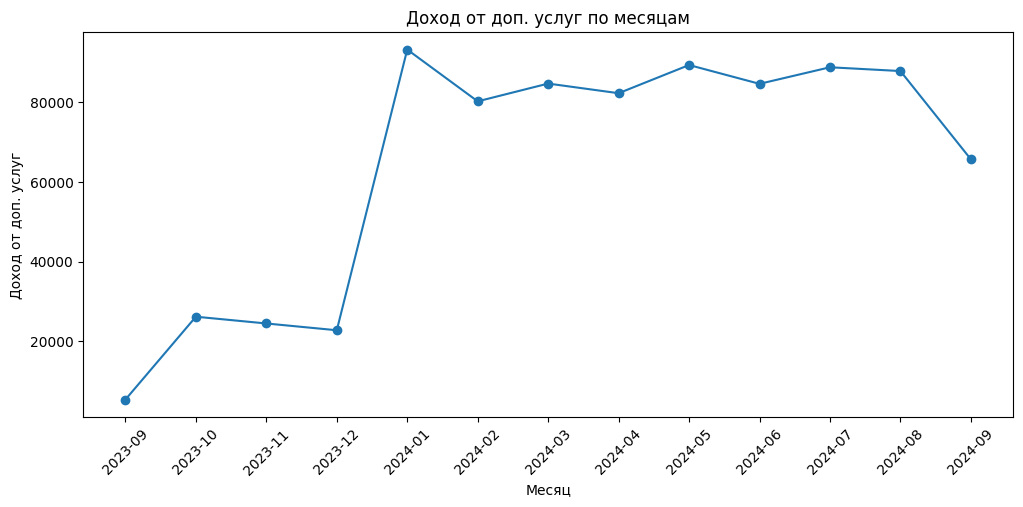

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    metrics["addons_by_month"]["month"],
    metrics["addons_by_month"]["addons_revenue"],
    marker="o",
)

plt.title("Доход от доп. услуг по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Доход от доп. услуг")
plt.xticks(rotation=45)

plt.show()

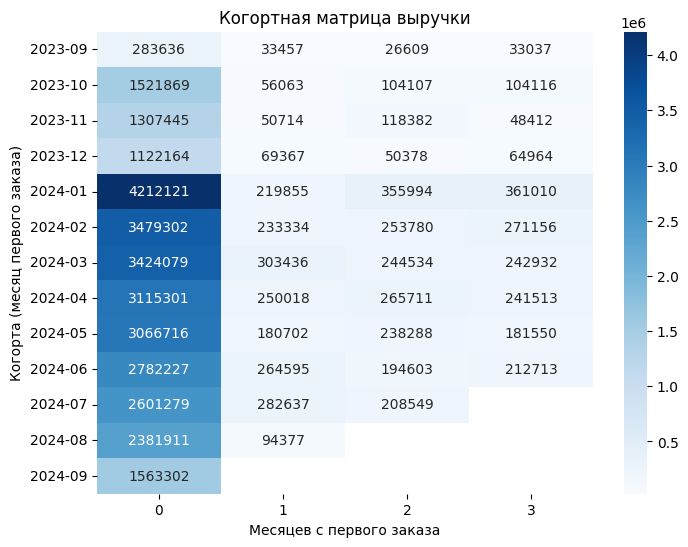

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    metrics["cohort_revenue"],
    annot=True,
    fmt=".0f",
    cmap="Blues",
)

plt.title("Когортная матрица выручки")
plt.xlabel("Месяцев с первого заказа")
plt.ylabel("Когорта (месяц первого заказа)")

plt.show()